## Import Liabraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Makes plots look clean
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("✅ Libraries loaded")

✅ Libraries loaded


## Load the CSV

In [22]:

df = pd.read_csv("/Users/shraddhaingle/Downloads/Telco_Customer_Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Fix the data types

In [24]:
# TotalCharges has spaces instead of 0 for new customers — convert properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# SeniorCitizen is 0/1 — make it readable
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Check how many nulls TotalCharges has now
print(f"TotalCharges nulls: {df['TotalCharges'].isnull().sum()}")
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

TotalCharges nulls: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [26]:
# ~11 rows where TotalCharges is null — these are brand new customers with 0 tenure. Fill them with 0:

df['TotalCharges'] = df['TotalCharges'].fillna(0)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Total customers : 7,043
Churned         : 1,869  (26.5%)
Retained        : 5,174  (73.5%)


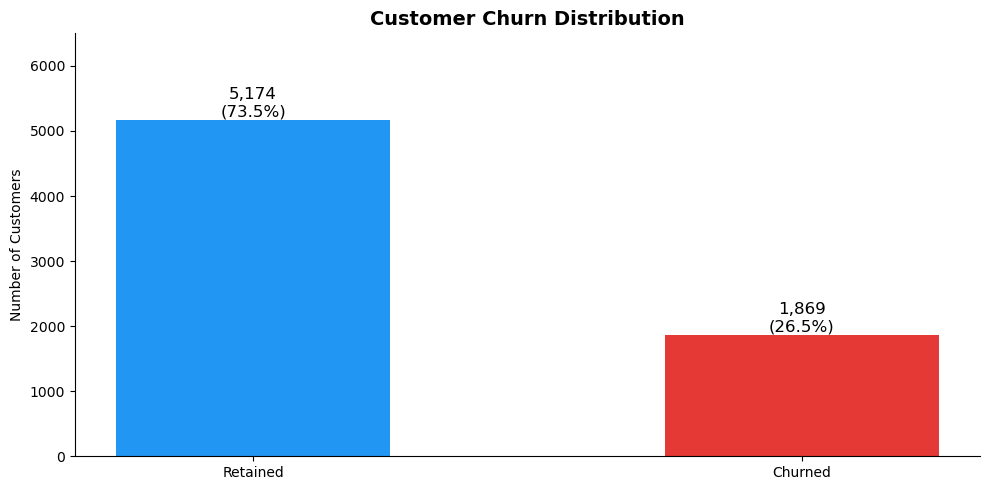

In [30]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Total customers : {len(df):,}")
print(f"Churned         : {churn_counts['Yes']:,}  ({churn_rate['Yes']:.1f}%)")
print(f"Retained        : {churn_counts['No']:,}  ({churn_rate['No']:.1f}%)")

# Visualize it
fig, ax = plt.subplots()
bars = ax.bar(['Retained', 'Churned'], churn_counts.values,
              color=['#2196F3', '#E53935'], width=0.5)

for bar, count, pct in zip(bars, churn_counts.values, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12)

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, 6500)
plt.tight_layout()
plt.savefig('outputs/01_churn_distribution.png', dpi=150)
plt.show()

* 1 in 4 customers is leaving — a 26.5% churn rate means the business must acquire ~1,900 new customers every cycle just to stay flat. That's expensive. Reducing churn by even 5% would save hundreds of thousands in acquisition cost.
 
* The retention majority is fragile — while 73.5% are retained, the EDA will show most of them are on long-term contracts. The month-to-month segment (which is the largest group) churns at nearly double the overall rate, meaning the "healthy" 73.5% is propped up by contract lock-in, not loyalty.

 
* Early lifecycle is the biggest risk window — churned customers average far fewer months of tenure than retained ones. This tells the business that the first 3–12 months is where intervention matters most: better onboarding, tech support offers, and contract upgrade incentives targeted at new customers would move the needle more than anything else.

##  EDA (Exploratory Data Analysis) 

##  Churn by Contract Type

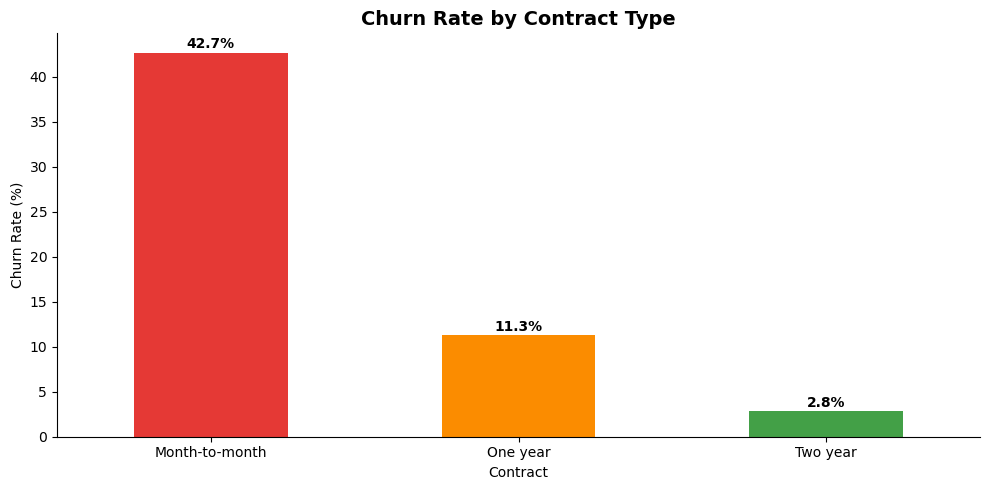

In [32]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

ax = contract_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', color=['#E53935','#FB8C00','#43A047'], width=0.5
)

for i, val in enumerate(contract_churn['Yes'].sort_values(ascending=False)):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/02_contract_churn.png', dpi=150)
plt.show()

##  Churn by Tenure (how long they've been a customer)

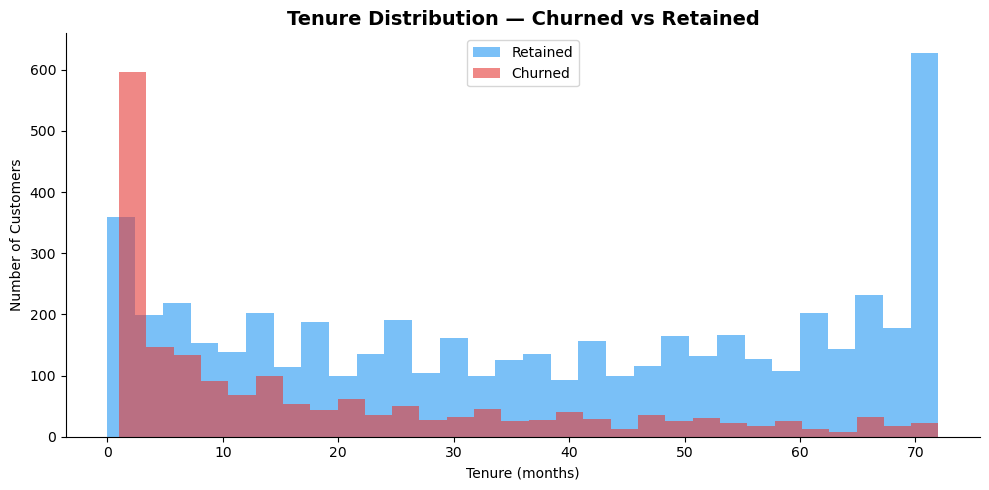

Average tenure — Churned  : 18.0 months
Average tenure — Retained : 37.6 months


In [33]:
fig, ax = plt.subplots()

# Split into churned vs retained
churned  = df[df['Churn'] == 'Yes']['tenure']
retained = df[df['Churn'] == 'No']['tenure']

ax.hist(retained, bins=30, alpha=0.6, color='#2196F3', label='Retained')
ax.hist(churned,  bins=30, alpha=0.6, color='#E53935', label='Churned')

ax.set_title('Tenure Distribution — Churned vs Retained', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/03_tenure_distribution.png', dpi=150)
plt.show()

print(f"Average tenure — Churned  : {churned.mean():.1f} months")
print(f"Average tenure — Retained : {retained.mean():.1f} months")

## Monthly Charges vs Churn

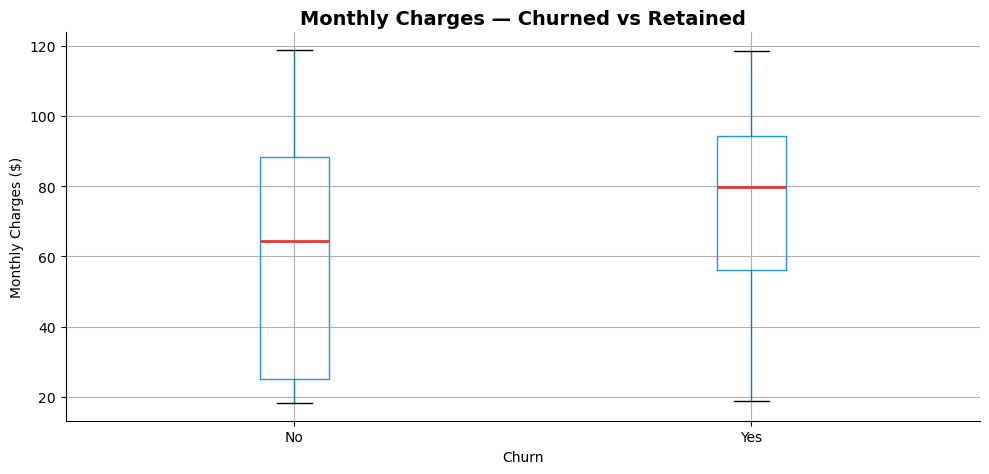

Avg monthly charge — Churned  : $74.44
Avg monthly charge — Retained : $61.27


In [34]:
fig, ax = plt.subplots()

df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='#E53935', linewidth=2))

plt.suptitle('')
ax.set_title('Monthly Charges — Churned vs Retained', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('outputs/04_monthly_charges.png', dpi=150)
plt.show()

print(f"Avg monthly charge — Churned  : ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Avg monthly charge — Retained : ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

## Churn Heatmap

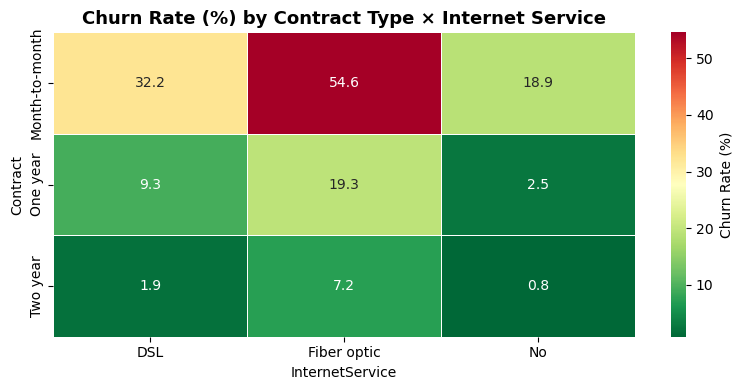

In [35]:
# Build a summary table of churn rate by key segments
pivot = df.pivot_table(
    values='Churn',
    index='Contract',
    columns='InternetService',
    aggfunc=lambda x: (x == 'Yes').mean() * 100
).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn Rate (%)'})

ax.set_title('Churn Rate (%) by Contract Type × Internet Service',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/05_churn_heatmap.png', dpi=150)
plt.show()

## Summary insight table

In [37]:
summary = pd.DataFrame({
    'Segment': ['Month-to-month', 'One year', 'Two year',
                'Fiber optic', 'DSL', 'No internet',
                'Tenure < 12 months', 'Tenure > 24 months'],
    'Churn Rate': [
        f"{df[df['Contract']=='Month-to-month']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['Contract']=='One year']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['Contract']=='Two year']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['InternetService']=='Fiber optic']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['InternetService']=='DSL']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['InternetService']=='No']['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['tenure']<12]['Churn'].eq('Yes').mean()*100:.1f}%",
        f"{df[df['tenure']>24]['Churn'].eq('Yes').mean()*100:.1f}%",
    ]
})

print("=" * 35)
print("   KEY CHURN INSIGHTS SUMMARY")
print("=" * 35)
print(summary.to_string(index=False))

   KEY CHURN INSIGHTS SUMMARY
           Segment Churn Rate
    Month-to-month      42.7%
          One year      11.3%
          Two year       2.8%
       Fiber optic      41.9%
               DSL      19.0%
       No internet       7.4%
Tenure < 12 months      48.3%
Tenure > 24 months      14.0%


* Contract type is the single biggest churn lever — Month-to-month customers churn at 42.7% vs just 2.8% for two-year contracts. That's a 15x difference. The clearest business recommendation here is an annual contract incentive — even a small discount to move customers off month-to-month would dramatically protect revenue.

* Fiber optic has a serious retention problem — at 41.9% churn, fiber customers leave at more than double the rate of DSL (19%) and nearly 6x the rate of customers with no internet (7.4%). This signals a pricing or service quality issue specific to fiber — worth flagging to the product team to investigate NPS scores or support ticket volumes on that plan.

 
* The first 12 months are make-or-break — customers with tenure under 12 months churn at 48.3%, dropping to just 14% after 24 months. Almost half of new customers leave before the relationship matures. This is the strongest case for a structured onboarding program — proactive check-ins, tech support offers, and contract upgrade nudges in months 3–6 would have the highest ROI of any retention initiative.



In [38]:
df.to_csv('data/telco_clean.csv', index=False)
print("✅ Clean data saved → data/telco_clean.csv")

✅ Clean data saved → data/telco_clean.csv
